# Logistic Regression with a Neural Network mindset

Welcome to your first programming assignment! You will build a logistic regression classifier to recognize cats. This assignment will step you through how to do this with a Neural Network mindset.

**Instructions:**
- Do not use loops (`for`/`while`) in your code, unless the instructions explicitly ask you to do so.

**You will learn to:**
- Build the general architecture of a learning algorithm, including:
  - Initializing parameters
  - Calculating the cost function and its gradient
  - Using an optimization algorithm (gradient descent)
- Gather all three functions above into a main model function, in the right order.

## 1 - Packages

Run the cell below to import the packages you'll need:
- `numpy` for scientific computing
- `h5py` to interact with the dataset stored as an H5 file
- `matplotlib` to plot graphs
- `PIL` and `scipy` to test your model with your own picture at the end

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import scipy
from PIL import Image
from scipy import ndimage
from lr_utils import load_dataset

%matplotlib inline

## 2 - Overview of the Problem set

**Problem Statement:** You are given a dataset (`data.h5`) containing:
- a training set of `m_train` images labeled as cat (y=1) or non-cat (y=0)
- a test set of `m_test` images labeled as cat or non-cat
- each image is of shape `(num_px, num_px, 3)` where 3 is for the 3 RGB channels. Each image is square (height = num_px, width = num_px).

You will build a simple image-recognition algorithm that can correctly classify pictures as cat or non-cat.

Load the data by running the following code.

In [2]:
# Loading the data (cat/non-cat)
train_set_x_orig, train_set_y, test_set_x_orig, test_set_y, classes = load_dataset()

We added `_orig` to the end of the image datasets since we're going to preprocess them. After preprocessing we'll end up with `train_set_x` and `test_set_x`.

You can visualize an example image with the code below. Feel free to change `index` to look at other pictures.

y = 0, it's a 'non-cat' picture.


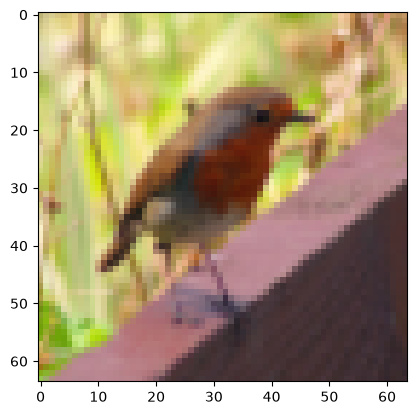

In [3]:
# Example of a picture
index = 10
plt.imshow(train_set_x_orig[index])
print("y = " + str(train_set_y[0, index]) + ", it's a '" + classes[np.squeeze(train_set_y[:, index])].decode("utf-8") + "' picture.")

Keeping your matrix/vector dimensions straight will save you from a lot of bugs.

**Exercise:** Find the values for:
- `m_train` — number of training examples
- `m_test` — number of test examples
- `num_px` — height (= width) of a training image

Remember `train_set_x_orig` is a numpy array of shape `(m_train, num_px, num_px, 3)`. You can access `m_train` with `train_set_x_orig.shape[0]`.

**Expected output:** `m_train = 209`, `m_test = 50`, `num_px = 64`

In [4]:
### START CODE HERE ###
m_train = train_set_x_orig.shape[0]
m_test = test_set_x_orig.shape[0]
num_px = train_set_x_orig.shape[2]
### END CODE HERE ###

print("Number of training examples: m_train = " + str(m_train))
print("Number of testing examples: m_test = " + str(m_test))
print("Height/Width of each image: num_px = " + str(num_px))
print("Each image is of size: (" + str(num_px) + ", " + str(num_px) + ", 3)")
print("train_set_x shape: " + str(train_set_x_orig.shape))
print("train_set_y shape: " + str(train_set_y.shape))
print("test_set_x shape: " + str(test_set_x_orig.shape))
print("test_set_y shape: " + str(test_set_y.shape))

Number of training examples: m_train = 209
Number of testing examples: m_test = 50
Height/Width of each image: num_px = 64
Each image is of size: (64, 64, 3)
train_set_x shape: (209, 64, 64, 3)
train_set_y shape: (1, 209)
test_set_x shape: (50, 64, 64, 3)
test_set_y shape: (1, 50)


For convenience, reshape images of shape `(num_px, num_px, 3)` into a numpy array of shape `(num_px * num_px * 3, 1)`. After this, the dataset is an array where each **column** represents a flattened image.

**Exercise:** Flatten `train_set_x_orig` and `test_set_x_orig` so each image becomes a single column.

Tip: to flatten a matrix `X` of shape `(a, b, c, d)` into `X_flatten` of shape `(b*c*d, a)`:
```
X_flatten = X.reshape(X.shape[0], -1).T
```

**Expected output:**
- `train_set_x_flatten shape`: (12288, 209)
- `test_set_x_flatten shape`: (12288, 50)
- sanity check: `[17 31 56 22 33]`

In [5]:
# Reshape the training and test examples
### START CODE HERE ###
train_set_x_flatten = train_set_x_orig.reshape(train_set_x_orig.shape[0], -1).T
test_set_x_flatten = test_set_x_orig.reshape(test_set_x_orig.shape[0], -1).T
### END CODE HERE ###

print("train_set_x_flatten shape: " + str(train_set_x_flatten.shape))
print("train_set_y shape: " + str(train_set_y.shape))
print("test_set_x_flatten shape: " + str(test_set_x_flatten.shape))
print("test_set_y shape: " + str(test_set_y.shape))
print("sanity check after reshaping: " + str(train_set_x_flatten[0:5,0]))

train_set_x_flatten shape: (12288, 209)
train_set_y shape: (1, 209)
test_set_x_flatten shape: (12288, 50)
test_set_y shape: (1, 50)
sanity check after reshaping: [17 31 56 22 33]


To center and standardize a dataset you'd normally subtract the mean and divide by the standard deviation. For picture data it's simpler (and works almost as well) to just divide every pixel value by 255, the max value of a channel.

Run the cell below to standardize the dataset.

In [6]:
train_set_x = train_set_x_flatten / 255.
test_set_x = test_set_x_flatten / 255.

**What to remember — common preprocessing steps:**
1. Figure out the dimensions/shapes of the problem (`m_train`, `m_test`, `num_px`, ...)
2. Reshape the datasets so each example is a vector of shape `(num_px * num_px * 3, 1)`
3. "Standardize" the data

## 3 - General Architecture of the learning algorithm

You'll build a Logistic Regression classifier using a Neural Network mindset.

**For one example $x^{(i)}$:**

$$z^{(i)} = w^T x^{(i)} + b$$
$$\hat{y}^{(i)} = a^{(i)} = sigmoid(z^{(i)})$$
$$\mathcal{L}(a^{(i)}, y^{(i)}) = -y^{(i)}\log(a^{(i)}) - (1-y^{(i)})\log(1-a^{(i)})$$

The cost is computed by summing over all training examples:

$$J = \frac{1}{m}\sum_{i=1}^m \mathcal{L}(a^{(i)}, y^{(i)})$$

**Key steps for this exercise:**
- Initialize the parameters of the model
- Learn the parameters by minimizing the cost
- Use the learned parameters to make predictions on the test set
- Analyze the results and conclude

## 4 - Building the parts of our algorithm

The main steps for building a Neural Network are:
1. Define the model structure (e.g. number of input features)
2. Initialize the model's parameters
3. Loop:
   - Calculate current loss (forward propagation)
   - Calculate current gradient (backward propagation)
   - Update parameters (gradient descent)

You'll build steps 1-3 separately, then integrate them into one function called `model()`.

### 4.1 - Helper functions

**Exercise:** Implement `sigmoid()`. You need $sigmoid(w^Tx+b) = \frac{1}{1+e^{-(w^Tx+b)}}$ to make predictions. Use `np.exp()`.

**Expected output:** `sigmoid([0, 2]) = [0.5, 0.88079708]`

In [8]:
# GRADED FUNCTION: sigmoid
def sigmoid(z):
    """
    Compute the sigmoid of z

    Arguments:
    z -- A scalar or numpy array of any size.

    Return:
    s -- sigmoid(z)
    """

    ### START CODE HERE ###
    s = 1/(1+np.exp(-z))
    ### END CODE HERE ###

    return s

In [9]:
print("sigmoid([0, 2]) = " + str(sigmoid(np.array([0, 2]))))

sigmoid([0, 2]) = [0.5        0.88079708]


### 4.2 - Initializing parameters

**Exercise:** Implement parameter initialization. `w` should be a vector of zeros. Look up `np.zeros()` if needed.

**Expected output:** `w = [[0.], [0.]]`, `b = 0`

Note: for image inputs, `w` will have shape `(num_px * num_px * 3, 1)`.

In [10]:
# GRADED FUNCTION: initialize_with_zeros
def initialize_with_zeros(dim):
    """
    Creates a vector of zeros of shape (dim, 1) for w and initializes b to 0.

    Argument:
    dim -- size of the w vector we want (number of parameters)

    Returns:
    w -- initialized vector of shape (dim, 1)
    b -- initialized scalar (bias)
    """

    ### START CODE HERE ###
    w = np.zeros((dim, 1))
    b = 0
    ### END CODE HERE ###

    assert(w.shape == (dim, 1))
    assert(isinstance(b, float) or isinstance(b, int))

    return w, b

In [11]:
dim = 2
w, b = initialize_with_zeros(dim)
print("w = " + str(w))
print("b = " + str(b))

w = [[0.]
 [0.]]
b = 0


### 4.3 - Forward and Backward propagation

**Exercise:** Implement `propagate()`, which computes the cost function and its gradient.

**Forward propagation:**
- Compute $A = \sigma(w^TX + b) = (a^{(1)}, a^{(2)}, ..., a^{(m)})$
- Compute the cost: $J = -\frac{1}{m}\sum_{i=1}^m y^{(i)}\log(a^{(i)}) + (1-y^{(i)})\log(1-a^{(i)})$

**Backward propagation (gradients):**

$$\frac{\partial J}{\partial w} = \frac{1}{m}X(A-Y)^T$$
$$\frac{\partial J}{\partial b} = \frac{1}{m}\sum_{i=1}^m (a^{(i)}-y^{(i)})$$

**Expected output:**
- `dw = [[0.99845601], [2.39507239]]`
- `db = 0.00145557813678`
- `cost = 5.801545319394553`

In [12]:
# GRADED FUNCTION: propagate
def propagate(w, b, X, Y):
    """
    Implement the cost function and its gradient for the propagation explained above

    Arguments:
    w -- weights, a numpy array of size (num_px * num_px * 3, 1)
    b -- bias, a scalar
    X -- data of size (num_px * num_px * 3, number of examples)
    Y -- true "label" vector (0 if non-cat, 1 if cat), of size (1, number of examples)

    Return:
    cost -- negative log-likelihood cost for logistic regression
    dw -- gradient of the loss with respect to w, same shape as w
    db -- gradient of the loss with respect to b, same shape as b

    Tips:
    - Write your code step by step. np.log(), np.dot() will be useful.
    """

    m = X.shape[1]

    # FORWARD PROPAGATION (FROM X TO COST)
    ### START CODE HERE ###
    Z = np.dot(w.T, X) + b
    A = sigmoid(Z)                                                  # compute activation
    cost = -(np.dot(Y, np.log(A).T) + np.dot((1-Y), np.log(1-A).T))/m     # compute cost
    ### END CODE HERE ###

    # BACKWARD PROPAGATION (TO FIND GRAD)
    ### START CODE HERE ###
    dZ = A-Y
    dw = np.dot(X,dZ.T)/m
    db = np.sum(dZ)/m
    ### END CODE HERE ###

    assert(dw.shape == w.shape)
    assert(db.dtype == float)
    cost = np.squeeze(cost)
    assert(cost.shape == ())

    grads = {"dw": dw, "db": db}

    return grads, cost

In [13]:
w, b, X, Y = np.array([[1.], [2.]]), 2., np.array([[1., 2., -1.], [3., 4., -3.2]]), np.array([[1, 0, 1]])
grads, cost = propagate(w, b, X, Y)
print("dw = " + str(grads["dw"]))
print("db = " + str(grads["db"]))
print("cost = " + str(cost))

dw = [[0.99845601]
 [2.39507239]]
db = 0.001455578136784208
cost = 5.801545319394553


### 4.4 - Optimization

Now update the parameters using gradient descent.

**Exercise:** Write the optimization function. For a parameter $\theta$, the update rule is $\theta = \theta - \alpha \, d\theta$, where $\alpha$ is the learning rate.

Loop:
1. Calculate the cost and gradient using `propagate()`
2. Update `w` and `b` using the gradient descent rule

**Expected output:**
- `w = [[0.19033591], [0.12259159]]`
- `b = 1.92535983008`
- `dw = [[0.67752042], [1.41625495]]`
- `db = 0.219194504541`

In [14]:
# GRADED FUNCTION: optimize
def optimize(w, b, X, Y, num_iterations, learning_rate, print_cost=False):
    """
    Optimizes w and b by running a gradient descent algorithm.

    Arguments:
    w -- weights, a numpy array of size (num_px * num_px * 3, 1)
    b -- bias, a scalar
    X -- data of shape (num_px * num_px * 3, number of examples)
    Y -- true "label" vector, of shape (1, number of examples)
    num_iterations -- number of iterations of the optimization loop
    learning_rate -- learning rate of the gradient descent update rule
    print_cost -- True to print the loss every 100 steps

    Returns:
    params -- dictionary containing the weights w and bias b
    grads -- dictionary containing the gradients of w and b
    costs -- list of costs computed during optimization (used to plot the learning curve)

    Tips:
    You basically need two steps, repeated in a loop:
        1) Calculate the cost and gradient for the current parameters using propagate().
        2) Update the parameters using the gradient descent rule for w and b.
    """

    costs = []

    for i in range(num_iterations):

        # Cost and gradient calculation
        ### START CODE HERE ###
        grads, cost = propagate(w, b, X, Y)
        ### END CODE HERE ###

        # Retrieve derivatives from grads
        dw = grads["dw"]
        db = grads["db"]

        # update rule
        ### START CODE HERE ###
        w = w - learning_rate*dw
        b = b - learning_rate*db
        ### END CODE HERE ###

        # Record the costs
        if i % 100 == 0:
            costs.append(cost)

        # Print the cost every 100 training iterations
        if print_cost and i % 100 == 0:
            print("Cost after iteration %i: %f" % (i, cost))

    params = {"w": w, "b": b}
    grads = {"dw": dw, "db": db}

    return params, grads, costs

In [15]:
params, grads, costs = optimize(w, b, X, Y, num_iterations=100, learning_rate=0.009, print_cost=False)

print("w = " + str(params["w"]))
print("b = " + str(params["b"]))
print("dw = " + str(grads["dw"]))
print("db = " + str(grads["db"]))

w = [[0.19033591]
 [0.12259159]]
b = 1.9253598300845747
dw = [[0.67752042]
 [1.41625495]]
db = 0.21919450454067657


**Exercise:** The `optimize()` function outputs the learned `w` and `b`. Use them to predict labels for a dataset `X` by implementing `predict()`:
1. Calculate $\hat{Y} = A = \sigma(w^TX + b)$
2. Convert entries of `A` into 0 (if activation <= 0.5) or 1 (if activation > 0.5), storing the predictions in `Y_prediction`. You can vectorize this without a loop.

**Expected output:** `predictions = [[1. 1. 0.]]`

In [17]:
# GRADED FUNCTION: predict
def predict(w, b, X):
    """
    Predict whether the label is 0 or 1 using learned logistic regression parameters (w, b)

    Arguments:
    w -- weights, a numpy array of size (num_px * num_px * 3, 1)
    b -- bias, a scalar
    X -- data of size (num_px * num_px * 3, number of examples)

    Returns:
    Y_prediction -- a numpy array (vector) containing all predictions (0/1) for the examples in X
    """

    m = X.shape[1]
    Y_prediction = np.zeros((1, m))
    w = w.reshape(X.shape[0], 1)

    # Compute vector "A" predicting the probability of a cat being present in the picture
    ### START CODE HERE ###
    Z = np.dot(w.T, X) + b
    A = sigmoid(Z)
    ### END CODE HERE ###

    ### START CODE HERE ###
    # Convert probabilities A[0, i] into actual predictions Y_prediction[0, i]
    Y_prediction = np.sign(np.maximum(np.log(2*A),0))
    ### END CODE HERE ###

    assert(Y_prediction.shape == (1, m))

    return Y_prediction

In [18]:
w = np.array([[0.1124579], [0.23106775]])
b = -0.3
X = np.array([[1., -1.1, -3.2], [1.2, 2., 0.1]])
print("predictions = " + str(predict(w, b, X)))

predictions = [[1. 1. 0.]]


**What to remember:** you've implemented several functions that:
- Initialize `(w, b)`
- Optimize the loss iteratively to learn `(w, b)`: computing the cost and its gradient, then updating the parameters using gradient descent
- Use the learned `(w, b)` to predict the labels for a given set of examples

## 5 - Merge all functions into a model

**Exercise:** Implement `model()`, putting the previous building blocks together, in the right order. Use:
- `Y_prediction_test` for your predictions on the test set
- `Y_prediction_train` for your predictions on the training set
- `w`, `costs`, `grads` for the outputs of `optimize()`

**Expected output (with the default hyperparameters below):**
- Cost after iteration 0: 0.693147
- Train Accuracy: ~99.04%
- Test Accuracy: ~70.0%

In [19]:
# GRADED FUNCTION: model
def model(X_train, Y_train, X_test, Y_test, num_iterations=2000, learning_rate=0.5, print_cost=False):
    """
    Builds the logistic regression model by calling the functions you've implemented previously.

    Arguments:
    X_train -- training set, shape (num_px * num_px * 3, m_train)
    Y_train -- training labels, shape (1, m_train)
    X_test -- test set, shape (num_px * num_px * 3, m_test)
    Y_test -- test labels, shape (1, m_test)
    num_iterations -- hyperparameter: number of iterations to optimize the parameters
    learning_rate -- hyperparameter: learning rate used in the update rule of optimize()
    print_cost -- set to True to print the cost every 100 iterations

    Returns:
    d -- dictionary containing information about the model
    """

    ### START CODE HERE ###

    # initialize parameters with zeros
    w, b = initialize_with_zeros(X_train.shape[0])

    # Gradient descent
    parameters, grads, costs = optimize(w,b,X_train,Y_train,num_iterations,learning_rate,print_cost)

    # Retrieve parameters w and b from dictionary "parameters"
    w = parameters["w"]
    b = parameters["b"]

    # Predict test/train set examples
    Y_prediction_test = predict(w,b,X_test)
    Y_prediction_train = predict(w,b,X_train)

    ### END CODE HERE ###

    # Print train/test Errors
    print("train accuracy: {} %".format(100 - np.mean(np.abs(Y_prediction_train - Y_train)) * 100))
    print("test accuracy: {} %".format(100 - np.mean(np.abs(Y_prediction_test - Y_test)) * 100))

    d = {"costs": costs,
         "Y_prediction_test": Y_prediction_test,
         "Y_prediction_train": Y_prediction_train,
         "w": w,
         "b": b,
         "learning_rate": learning_rate,
         "num_iterations": num_iterations}

    return d

In [20]:
d = model(train_set_x, train_set_y, test_set_x, test_set_y, num_iterations=2000, learning_rate=0.005, print_cost=True)

Cost after iteration 0: 0.693147
Cost after iteration 100: 0.584508
Cost after iteration 200: 0.466949
Cost after iteration 300: 0.376007
Cost after iteration 400: 0.331463
Cost after iteration 500: 0.303273
Cost after iteration 600: 0.279880
Cost after iteration 700: 0.260042
Cost after iteration 800: 0.242941
Cost after iteration 900: 0.228004
Cost after iteration 1000: 0.214820
Cost after iteration 1100: 0.203078
Cost after iteration 1200: 0.192544
Cost after iteration 1300: 0.183033
Cost after iteration 1400: 0.174399
Cost after iteration 1500: 0.166521
Cost after iteration 1600: 0.159305
Cost after iteration 1700: 0.152667
Cost after iteration 1800: 0.146542
Cost after iteration 1900: 0.140872
train accuracy: 99.04306220095694 %
test accuracy: 70.0 %


Run the cell below (change `index`) to look at predictions on pictures of the test set.

y = 0, you predicted that it is a "non-cat" picture.


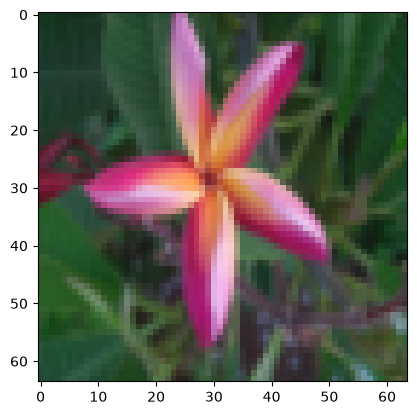

In [40]:
# Example of a picture that was wrongly classified.
index = 16
plt.imshow(test_set_x[:, index].reshape((num_px, num_px, 3)))
print("y = " + str(test_set_y[0, index]) + ", you predicted that it is a \"" + classes[int(d["Y_prediction_test"][0, index])].decode("utf-8") + "\" picture.")

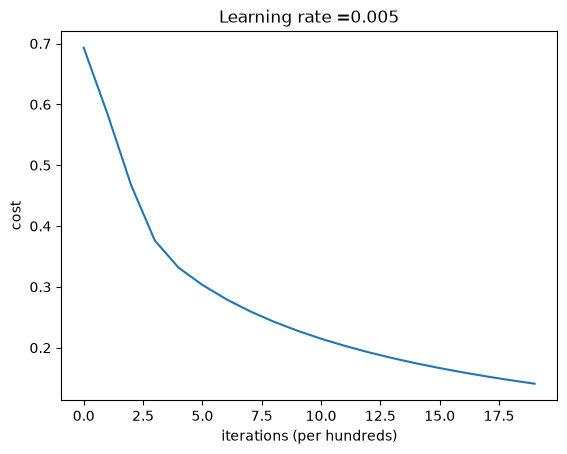

In [41]:
# Plot learning curve (with costs)
costs = np.squeeze(d['costs'])
plt.plot(costs)
plt.ylabel('cost')
plt.xlabel('iterations (per hundreds)')
plt.title("Learning rate =" + str(d["learning_rate"]))
plt.show()

**Interpretation:** the cost should be decreasing, showing that the parameters are being learned. Try increasing the number of iterations and rerunning — training accuracy may go up while test accuracy goes down. This is called overfitting.

## 6 - Further analysis (optional/ungraded exercise)

Let's examine possible choices for the learning rate $\alpha$.

**Reminder:** the learning rate determines how rapidly the parameters update. Too large and you may overshoot the optimum; too small and you'll need many more iterations to converge. Run the cell below to compare a few learning rates (takes about a minute). Feel free to try other values.

learning rate is: 0.01
train accuracy: 99.52153110047847 %
test accuracy: 68.0 %

-------------------------------------------------------

learning rate is: 0.001
train accuracy: 88.99521531100478 %
test accuracy: 64.0 %

-------------------------------------------------------

learning rate is: 0.0001
train accuracy: 68.42105263157895 %
test accuracy: 36.0 %

-------------------------------------------------------



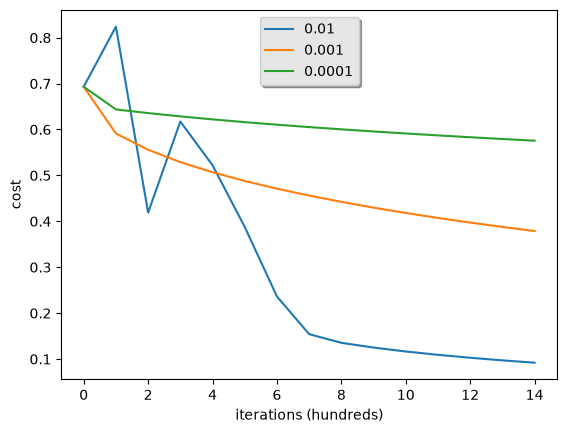

In [44]:
learning_rates = [0.01, 0.001, 0.0001]
models = {}
for i in learning_rates:
    print("learning rate is: " + str(i))
    models[str(i)] = model(train_set_x, train_set_y, test_set_x, test_set_y, num_iterations=1500, learning_rate=i, print_cost=False)
    print('\n' + "-------------------------------------------------------" + '\n')

for i in learning_rates:
    plt.plot(np.squeeze(models[str(i)]["costs"]), label=str(models[str(i)]["learning_rate"]))

plt.ylabel('cost')
plt.xlabel('iterations (hundreds)')

legend = plt.legend(loc='upper center', shadow=True)
frame = legend.get_frame()
frame.set_facecolor('0.90')
plt.show()

## 7 - Test with your own image (optional/ungraded exercise)

To test with your own picture:
1. Add your image to this notebook's `images/` folder
2. Change `my_image` below to your file's name
3. Run the cell and check the prediction (1 = cat, 0 = non-cat)

y = 1.0, your algorithm predicts a "cat" picture.


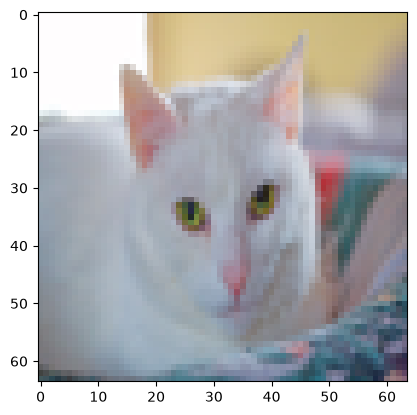

In [50]:
## START CODE HERE ## (PUT YOUR IMAGE NAME)
my_image = "my_image2.jpg"   # change this to the name of your image file
## END CODE HERE ##

# We preprocess the image to fit your algorithm.
fname = "images/" + my_image
image = np.array(Image.open(fname).resize((num_px, num_px)))
image = image / 255.
my_image_flat = image.reshape((1, num_px * num_px * 3)).T
my_predicted_image = predict(d["w"], d["b"], my_image_flat)

plt.imshow(image)
print("y = " + str(np.squeeze(my_predicted_image)) + ", your algorithm predicts a \"" + classes[int(np.squeeze(my_predicted_image))].decode("utf-8") + "\" picture.")

---
**What to remember from this assignment:**
1. Preprocessing the dataset is important.
2. You implemented each function separately: `initialize_with_zeros()`, `propagate()`, `optimize()`, `predict()` — then built a `model()`.
3. Tuning the learning rate (an example of a "hyperparameter") can make a big difference to the algorithm.

*Note: you'll need `lr_utils.py` and the dataset files (`train_catvnoncat.h5`, `test_catvnoncat.h5`) from your own course materials in the same folder as this notebook for the loading cell to work.*